# Notebook 02 — ML Risk Prediction Demo

This notebook extends the R-based survival analysis with a Python machine learning approach. The prediction task is **death within 3 years of diagnosis** among TCGA-BRCA patients.

A principled **censoring-aware** outcome definition is used: patients censored before 3 years are excluded from model training and evaluation because their 3-year status is genuinely unknown. This avoids the common error of treating early-censored patients as survivors.

**Pipeline overview:**

| Step | Tool |
|---|---|
| Data cleaning | `R/02_clean_tcga_cdr.R` |
| Survival analysis | `R/04_kaplan_meier.R`, `R/05_cox_regression.R` |
| ML risk prediction | This notebook |
| Interactive dashboard | `app_1.py` (Streamlit) |

**Input:** `data/processed/brca_survival_clean.csv`  
**Outputs:** model comparison CSV, test predictions CSV, and figures saved to `data/processed/` and `figures/`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

## Data

The analysis-ready cohort is loaded from `data/processed/brca_survival_clean.csv` — produced by `R/02_clean_tcga_cdr.R`. It contains **1 083 TCGA-BRCA patients** who have confirmed overall survival information (no missing event or follow-up time).

Key variables used in this notebook:

| Variable | Type | Description |
|---|---|---|
| `age` | continuous | Age at initial diagnosis |
| `stage_group` | ordinal (encoded as nominal) | Collapsed AJCC stage (I–IV) |
| `race`, `menopause_status`, `histological_type` | categorical | Secondary clinical covariates |
| `os_event` | binary | 1 = death observed, 0 = censored |
| `os_time_months` | continuous | Follow-up duration in months |

In [2]:
DATA_DIR = Path("../data/processed")
FIG_DIR = Path("../figures")

FIG_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_DIR / "brca_survival_clean.csv")

print("Dataset shape:", df.shape)
display(df.head())
display(df.dtypes)

Dataset shape: (1083, 13)


,patient_id,cancer_type,age,gender,race,menopause_status,histological_type,stage_raw,os_event,os_time_days,os_time_months,stage_group,age_group
0,TCGA-3C-AAAU,BRCA,55,FEMALE,WHITE,Pre (<6 months since LMP AND no prior bilatera...,Infiltrating Lobular Carcinoma,Stage X,0,4047,132.950066,NaN,50-64
1,TCGA-3C-AALI,BRCA,50,FEMALE,BLACK OR AFRICAN AMERICAN,Post (prior bilateral ovariectomy OR >12 mo si...,Infiltrating Ductal Carcinoma,Stage IIB,0,4005,131.570302,Stage II,50-64
2,TCGA-3C-AALJ,BRCA,62,FEMALE,BLACK OR AFRICAN AMERICAN,Post (prior bilateral ovariectomy OR >12 mo si...,Infiltrating Ductal Carcinoma,Stage IIB,0,1474,48.423127,Stage II,50-64
3,TCGA-3C-AALK,BRCA,52,FEMALE,BLACK OR AFRICAN AMERICAN,NaN,Infiltrating Ductal Carcinoma,Stage IA,0,1448,47.568988,Stage I,50-64
4,TCGA-4H-AAAK,BRCA,50,FEMALE,WHITE,Post (prior bilateral ovariectomy OR >12 mo si...,Infiltrating Lobular Carcinoma,Stage IIIA,0,348,11.432326,Stage III,50-64


patient_id               str
cancer_type              str
age                    int64
gender                   str
race                     str
menopause_status         str
histological_type        str
stage_raw                str
os_event               int64
os_time_days           int64
os_time_months       float64
stage_group              str
age_group                str
dtype: object

## Outcome: censoring-aware 3-year mortality label

The prediction target is **death within 3 years (36 months) of diagnosis**. Because the dataset contains right-censored observations, a naïve approach of treating all non-events as survivors would introduce outcome misclassification. Instead, a principled three-way classification is applied:

| Status label | Condition | ML label |
|---|---|---|
| `death_within_3y` | `os_event = 1` AND `os_time_months ≤ 36` | y = 1 |
| `known_no_death_within_3y` | `os_time_months > 36` (alive or died after 3 y) | y = 0 |
| `unknown_censored_before_3y` | `os_event = 0` AND `os_time_months ≤ 36` | **Excluded** |

Patients censored before 3 years (n = 576, 53.2 %) are excluded because their 3-year outcome is genuinely unknown. This is the same principle applied in landmark analyses and competing-risks frameworks in clinical epidemiology. Retaining them and labelling them as survivors would systematically underestimate the true risk — a form of informative censoring bias.

In [3]:
three_years = 36.0

ml_df = df.copy()

ml_df["death_within_3y"] = np.nan
ml_df["three_year_status"] = "unknown_censored_before_3y"

# Event: death within 3 years
ml_df.loc[
    (ml_df["os_event"] == 1) & (ml_df["os_time_months"] <= three_years),
    "death_within_3y"
] = 1

ml_df.loc[
    (ml_df["os_event"] == 1) & (ml_df["os_time_months"] <= three_years),
    "three_year_status"
] = "death_within_3y"

# Known non-event: followed beyond 3 years without death before 3 years
# This includes patients censored after 3 years and patients who died after 3 years.
ml_df.loc[
    ml_df["os_time_months"] > three_years,
    "death_within_3y"
] = 0

ml_df.loc[
    ml_df["os_time_months"] > three_years,
    "three_year_status"
] = "known_no_death_within_3y"

status_summary = (
    ml_df["three_year_status"]
    .value_counts(dropna=False)
    .reset_index()
)

status_summary.columns = ["three_year_status", "n"]
status_summary["percent"] = round(100 * status_summary["n"] / len(ml_df), 1)

display(status_summary)

status_summary.to_csv(DATA_DIR / "brca_ml_three_year_status_summary.csv", index=False)

,three_year_status,n,percent
0,unknown_censored_before_3y,576,53.2
1,known_no_death_within_3y,438,40.4
2,death_within_3y,69,6.4


## ML dataset construction

After excluding patients with an unknown 3-year outcome (censored before 3 years) and the small fraction with missing age or stage, the final ML dataset contains **493 patients**: 426 survivors (86.4 %) and 67 deaths (13.6 %).

The five candidate features span clinical and pathological covariates available in the TCGA-CDR table:

- **Age** (continuous) — z-score standardised inside the pipeline
- **Stage group** (ordinal, encoded as nominal one-hot) — the primary prognostic driver in breast cancer
- **Race**, **menopause status**, **histological type** (categorical) — secondary covariates with missing rates of ~7.7 %, ~7.7 %, and ~0.1 % respectively; imputed inside the pipeline

The **13.6 % event rate** represents substantial class imbalance. This is handled by setting `class_weight="balanced"` in Logistic Regression and Random Forest, which up-weights minority-class observations during training.

> **Limitation:** ER/PR/HER2 receptor status and tumour grade — the strongest prognostic markers in breast cancer — are not present in the TCGA-CDR clinical table used here. Their absence limits the predictive ceiling of any model trained on these features alone.

In [4]:
candidate_features = [
    "age",
    "stage_group",
    "race",
    "menopause_status",
    "histological_type",
]

available_features = [col for col in candidate_features if col in ml_df.columns]

ml_model_df = ml_df.dropna(subset=["death_within_3y"]).copy()
ml_model_df["death_within_3y"] = ml_model_df["death_within_3y"].astype(int)

# For this first ML version, age and stage are required.
# Other categorical variables are imputed inside the pipeline.
ml_model_df = ml_model_df.dropna(subset=["age", "stage_group"])

X = ml_model_df[available_features]
y = ml_model_df["death_within_3y"]

print("Available features:", available_features)
print("ML dataset shape:", ml_model_df.shape)

display(y.value_counts().rename("n"))
display(y.value_counts(normalize=True).round(3).rename("proportion"))

display(X.head())

Available features: ['age', 'stage_group', 'race', 'menopause_status', 'histological_type']
ML dataset shape: (493, 15)


death_within_3y
0    426
1     67
Name: n, dtype: int64

death_within_3y
0    0.864
1    0.136
Name: proportion, dtype: float64

,age,stage_group,race,menopause_status,histological_type
1,50,Stage II,BLACK OR AFRICAN AMERICAN,Post (prior bilateral ovariectomy OR >12 mo si...,Infiltrating Ductal Carcinoma
2,62,Stage II,BLACK OR AFRICAN AMERICAN,Post (prior bilateral ovariectomy OR >12 mo si...,Infiltrating Ductal Carcinoma
3,52,Stage I,BLACK OR AFRICAN AMERICAN,NaN,Infiltrating Ductal Carcinoma
5,42,Stage II,WHITE,Post (prior bilateral ovariectomy OR >12 mo si...,Infiltrating Lobular Carcinoma
6,63,Stage IV,WHITE,Post (prior bilateral ovariectomy OR >12 mo si...,Infiltrating Lobular Carcinoma


### Train / test split

The labelled dataset is split 75 % training / 25 % test using **stratified** splitting (`stratify=y`), which preserves the 86:14 class ratio in both partitions. A fixed `random_state=42` ensures reproducibility.

This yields 369 training and 124 test observations. With approximately 50 positive-class events in training and 17 in the test set, standard errors around AUC and other metrics will be wide — results should be interpreted as indicative rather than definitive. External validation on an independent cohort would be required before drawing clinical conclusions.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train event rate:", round(y_train.mean(), 3))
print("Test event rate:", round(y_test.mean(), 3))

Train shape: (369, 5)
Test shape: (124, 5)
Train event rate: 0.136
Test event rate: 0.137


### Preprocessing pipeline

All feature engineering is encapsulated in a `ColumnTransformer` to prevent **data leakage**: the transformers are fitted exclusively on training data and then applied to the test set — the test set never influences any fitted statistics.

- **Numeric (`age`):** median imputation (no missing values here, but included for pipeline robustness) → z-score standardisation with `StandardScaler`.
- **Categorical features:** mode imputation (`most_frequent`) for the ~7.7 % missing in `race` and `menopause_status` → one-hot encoding with `drop="first"` (avoids perfect multicollinearity) and `handle_unknown="ignore"` (gracefully handles categories seen in test but not training).

In [6]:
numeric_features = ["age"]
categorical_features = [c for c in available_features if c not in numeric_features]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    sparse_threshold=0,
)

### Model definitions

Three classifiers are compared, spanning the interpretability–complexity spectrum:

| Model | Rationale |
|---|---|
| **Logistic regression** | Fully interpretable baseline; coefficients are directly readable as log-odds and allow comparison with the Cox regression hazard ratios |
| **Random forest** | Ensemble method that captures non-linear interactions; regularised via `max_depth=4` and `min_samples_leaf=10` to reduce overfitting on this small dataset |
| **Gradient boosting** (`HistGradientBoostingClassifier`) | Sequential boosting; `max_leaf_nodes=15` and `learning_rate=0.05` provide mild regularisation |

`class_weight="balanced"` is applied to Logistic Regression and Random Forest to up-weight the minority class (deaths) during training. Note that `HistGradientBoostingClassifier` handles class imbalance differently — via `sample_weight` — and is included here without explicit class balancing as a comparison point.

In [7]:
models = {
    "Logistic regression": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    ),
    "Random forest": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=500,
                    max_depth=4,
                    min_samples_leaf=10,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    ),
    "Gradient boosting": Pipeline(
        steps=[
            ("preprocess", preprocessor),
            (
                "classifier",
                HistGradientBoostingClassifier(
                    max_iter=200,
                    learning_rate=0.05,
                    max_leaf_nodes=15,
                    random_state=42,
                ),
            ),
        ]
    ),
}

### Cross-validation for model selection

A **5-fold stratified cross-validation** is performed on the full labelled dataset to estimate generalisation AUC before the held-out test set is touched. Stratification (`StratifiedKFold`) maintains the 86:14 class ratio within every fold.

Cross-validation AUC results:

- **Logistic regression: 0.743 ± 0.032** — best generalisation performance.
- **Random forest: 0.692 ± 0.036** — moderate, benefits from the non-linear structure.
- **Gradient boosting: 0.587 ± 0.040** — underperforms; complex models overfit more easily with ~500 observations and a sparse outcome.

The clear advantage of the simple linear model over tree-based models reflects two realities: (1) the sample size is small, and (2) the underlying signal (stage → mortality) is largely monotone and near-linear, making logistic regression an appropriate choice. This pattern is consistent with the Cox regression results in `R/05_cox_regression.R`.

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

cv_results = []

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
    )

    cv_results.append(
        {
            "model": model_name,
            "cv_auc_mean": scores.mean(),
            "cv_auc_sd": scores.std(),
        }
    )

cv_results_df = pd.DataFrame(cv_results)

cv_results_df["cv_auc_mean"] = cv_results_df["cv_auc_mean"].round(3)
cv_results_df["cv_auc_sd"] = cv_results_df["cv_auc_sd"].round(3)

display(cv_results_df)

,model,cv_auc_mean,cv_auc_sd
0,Logistic regression,0.743,0.032
1,Random forest,0.692,0.036
2,Gradient boosting,0.587,0.040


## Model fitting and test-set evaluation

Each model is fitted on the training set and evaluated on the held-out test set. Metrics are computed at the default 0.5 probability threshold.

Key metrics reported:

| Metric | Interpretation |
|---|---|
| **AUC** | Discrimination ability; threshold-independent; 0.5 = chance |
| **Balanced accuracy** | Average of sensitivity and specificity; appropriate for imbalanced classes |
| **Sensitivity (recall)** | Proportion of actual deaths correctly predicted |
| **Specificity** | Proportion of survivors correctly predicted |
| **Precision** | Proportion of positive predictions that are true deaths |
| **F1** | Harmonic mean of precision and recall |

Given the 13.6 % event rate, precision will be limited even for a good model — a well-calibrated model predicting 0.14 probability for everyone would achieve ~86 % accuracy but 0 % sensitivity. Balanced accuracy and AUC are therefore the primary evaluation metrics here.

In [9]:
results = []
predictions = {}

# Balanced sample weights for gradient boosting, which does not accept
# class_weight="balanced" directly (unlike LogisticRegression and RandomForest).
# compute_sample_weight replicates the same up-weighting of the minority class.
sample_weights_train = compute_sample_weight("balanced", y_train)

for model_name, model in models.items():
    if model_name == "Gradient boosting":
        model.fit(X_train, y_train, classifier__sample_weight=sample_weights_train)
    else:
        model.fit(X_train, y_train)

    pred_prob = model.predict_proba(X_test)[:, 1]
    pred_label = (pred_prob >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, pred_label).ravel()

    results.append(
        {
            "model": model_name,
            "auc": roc_auc_score(y_test, pred_prob),
            "accuracy": accuracy_score(y_test, pred_label),
            "balanced_accuracy": balanced_accuracy_score(y_test, pred_label),
            "sensitivity_recall": recall_score(y_test, pred_label, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
            "precision": precision_score(y_test, pred_label, zero_division=0),
            "f1": f1_score(y_test, pred_label, zero_division=0),
            "true_negative": tn,
            "false_positive": fp,
            "false_negative": fn,
            "true_positive": tp,
        }
    )

    predictions[model_name] = {
        "prob": pred_prob,
        "label": pred_label,
    }

results_df = pd.DataFrame(results).sort_values("auc", ascending=False)

metric_cols = [
    "auc",
    "accuracy",
    "balanced_accuracy",
    "sensitivity_recall",
    "specificity",
    "precision",
    "f1",
]

results_df[metric_cols] = results_df[metric_cols].round(3)


results_df = results_df.merge(cv_results_df, on="model", how="left")

display(results_df)

results_df.to_csv(DATA_DIR / "brca_ml_model_comparison.csv", index=False)

c:\Users\henry\Documents\Research\phD\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\henry\Documents\Research\phD\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\henry\Documents\Research\phD\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,model,auc,accuracy,balanced_accuracy,sensitivity_recall,specificity,precision,f1,true_negative,false_positive,false_negative,true_positive,cv_auc_mean,cv_auc_sd
0,Logistic regression,0.720,0.694,0.699,0.706,0.692,0.267,0.387,74,33,5,12,0.743,0.032
1,Random forest,0.671,0.685,0.620,0.529,0.710,0.225,0.316,76,31,8,9,0.692,0.036
2,Gradient boosting,0.651,0.710,0.634,0.529,0.738,0.243,0.333,79,28,8,9,0.587,0.040


## ROC curves

The Receiver Operating Characteristic (ROC) curve plots the True Positive Rate (sensitivity) against the False Positive Rate (1 − specificity) across all classification thresholds. The **Area Under the Curve (AUC)** summarises discrimination: 0.5 = random classifier, 1.0 = perfect.

All three models exceed the chance diagonal. Logistic Regression achieves the highest test-set AUC (0.72), consistent with the cross-validation findings. The figure is saved to `figures/brca_ml_roc_curves.png` for use in the Streamlit dashboard.

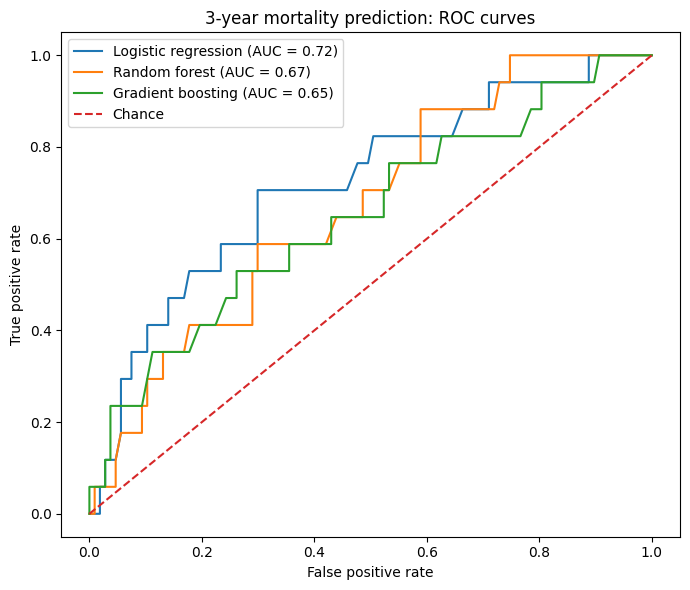

In [10]:
plt.figure(figsize=(7, 6))

for model_name, preds in predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds["prob"])
    auc = roc_auc_score(y_test, preds["prob"])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("3-year mortality prediction: ROC curves")
plt.legend()
plt.tight_layout()

plt.savefig(FIG_DIR / "brca_ml_roc_curves.png", dpi=300)
plt.show()

## Calibration curves

**Calibration** measures whether predicted probabilities match observed event rates. A model with AUC = 0.72 may still be poorly calibrated — for example, predicting 40 % risk for patients who actually die at a 14 % rate. For clinical risk prediction, calibration matters as much as discrimination.

The calibration curve plots the mean predicted probability against the observed fraction of positives within bins of predicted probability. A perfectly calibrated model follows the diagonal. The **Brier score** is a single-number summary: lower is better (0 = perfect, 0.25 = uninformative for a 50:50 outcome).

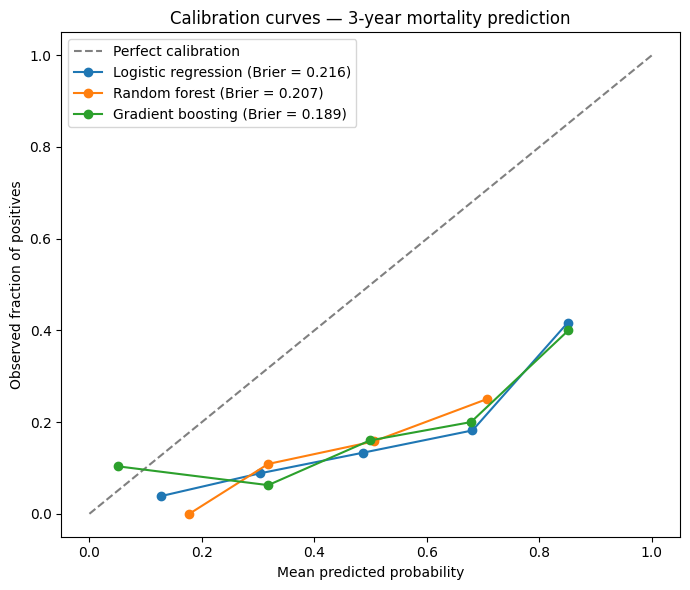

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")

for model_name, preds in predictions.items():
    prob_true, prob_pred = calibration_curve(
        y_test, preds["prob"], n_bins=5, strategy="uniform"
    )
    brier = brier_score_loss(y_test, preds["prob"])
    ax.plot(prob_pred, prob_true, marker="o", label=f"{model_name} (Brier = {brier:.3f})")

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed fraction of positives")
ax.set_title("Calibration curves — 3-year mortality prediction")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "brca_ml_calibration_curves.png", dpi=300)
plt.show()

## Model comparison

A horizontal bar chart summarises test-set AUC across the three models. Logistic Regression outperforms the tree-based models on both the test set and in cross-validation, which reflects two factors: (1) the sample size is modest (~500 observations), and (2) the dominant signal — pathological stage — follows a near-monotone ordinal relationship with mortality, which a linear model captures efficiently without the high variance of tree ensembles.

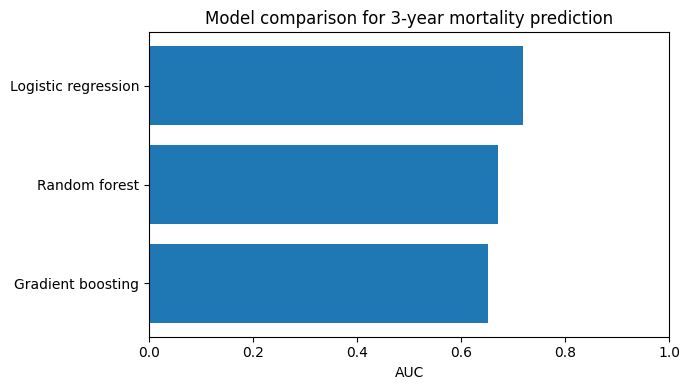

In [12]:
plot_df = results_df.sort_values("auc", ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(plot_df["model"], plot_df["auc"])
plt.xlabel("AUC")
plt.title("Model comparison for 3-year mortality prediction")
plt.xlim(0.0, 1.0)
plt.tight_layout()

plt.savefig(FIG_DIR / "brca_ml_auc_comparison.png", dpi=300)
plt.show()

### Random Forest — feature importance

Mean decrease in impurity (Gini importance) is extracted for each one-hot encoded feature. Age and Stage IV are the dominant predictors, consistent with both clinical knowledge and the Cox regression hazard ratios in `R/05_cox_regression.R`.

The top-15 features are displayed and saved to `data/processed/brca_ml_feature_importance.csv` for the Streamlit dashboard.

> **Note:** Gini importance can be biased towards high-cardinality features. For a more statistically rigorous alternative, `sklearn.inspection.permutation_importance` on the test set provides an unbiased estimate — a worthwhile addition in a production model.

In [13]:
rf_model = models["Random forest"]

rf_classifier = rf_model.named_steps["classifier"]
rf_preprocessor = rf_model.named_steps["preprocess"]

feature_names = rf_preprocessor.get_feature_names_out()
importances = rf_classifier.feature_importances_

feature_importance = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "importance": importances,
        }
    )
    .sort_values("importance", ascending=False)
    .head(15)
)

display(feature_importance)

feature_importance.to_csv(DATA_DIR / "brca_ml_feature_importance.csv", index=False)

,feature,importance
0,num__age,0.367582
2,cat__stage_group_Stage III,0.210482
8,cat__menopause_status_Pre (<6 months since LMP...,0.117909
1,cat__stage_group_Stage II,0.094721
7,cat__menopause_status_Post (prior bilateral ov...,0.081226
4,cat__race_BLACK OR AFRICAN AMERICAN,0.050873
5,cat__race_WHITE,0.045318
10,cat__histological_type_Infiltrating Lobular Ca...,0.018842
13,cat__histological_type_Mixed Histology (please...,0.010192
3,cat__stage_group_Stage IV,0.001661


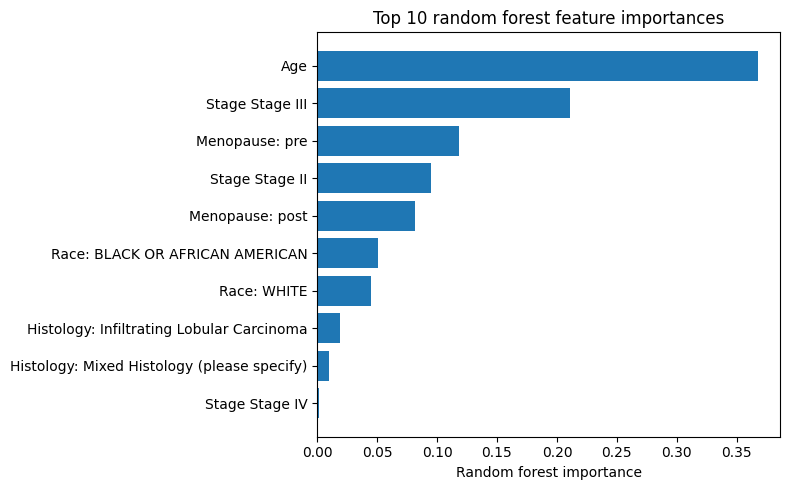

In [14]:
def clean_feature_label(feature: str) -> str:
    label = feature

    label = label.replace("num__", "")
    label = label.replace("cat__", "")

    if label == "age":
        return "Age"

    label = label.replace("stage_group_", "Stage ")
    label = label.replace("race_", "Race: ")
    label = label.replace("histological_type_", "Histology: ")

    if label.startswith("menopause_status_"):
        value = label.replace("menopause_status_", "")

        if value.startswith("Pre"):
            return "Menopause: pre"
        if value.startswith("Post"):
            return "Menopause: post"
        if value.startswith("Peri"):
            return "Menopause: peri"
        if value.startswith("Indeterminate"):
            return "Menopause: indeterminate"

        return "Menopause: other/unknown"

    return label

feature_importance["clean_feature"] = feature_importance["feature"].apply(
    clean_feature_label
)

plot_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .head(10)
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(8, 5))
plt.barh(plot_importance["clean_feature"], plot_importance["importance"])
plt.xlabel("Random forest importance")
plt.title("Top 10 random forest feature importances")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "brca_ml_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Exporting results

The model comparison table and test-set predictions (including predicted probabilities from all three models) are saved to `data/processed/` for consumption by the Streamlit dashboard (`app_1.py`). The best model is identified by the highest test-set AUC — Logistic Regression in this run.

In [15]:
best_model_name = results_df.iloc[0]["model"]

predictions_df = X_test.copy()
predictions_df["true_death_within_3y"] = y_test.values

for model_name, preds in predictions.items():
    safe_name = (
        model_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
    )
    predictions_df[f"{safe_name}_prob"] = preds["prob"]
    predictions_df[f"{safe_name}_label"] = preds["label"]

predictions_df.to_csv(DATA_DIR / "brca_ml_test_predictions.csv", index=False)

print("Best model by AUC:", best_model_name)

Best model by AUC: Logistic regression


## Confusion matrix — best model (Logistic Regression)

The confusion matrix shows the breakdown of true vs. predicted labels at the 0.5 threshold. Because `class_weight="balanced"` up-weights the minority class during training, the model trades some specificity for higher sensitivity — it correctly identifies more true deaths at the cost of more false positives among survivors.

In a clinical screening context, higher sensitivity (fewer missed deaths) is typically preferred over higher precision, provided the false-positive rate remains clinically acceptable.

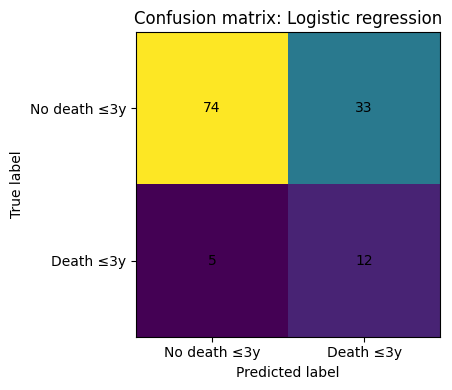

In [16]:
best_model_name = results_df.sort_values("auc", ascending=False).iloc[0]["model"]
best_preds = predictions[best_model_name]["label"]

cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_title(f"Confusion matrix: {best_model_name}")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No death ≤3y", "Death ≤3y"])
ax.set_yticklabels(["No death ≤3y", "Death ≤3y"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(FIG_DIR / "brca_ml_confusion_matrix_best_model.png", dpi=300)
plt.show()

### Logistic Regression — odds ratios

Exponentiated coefficients (odds ratios) from the Logistic Regression model are plotted in order of effect size. Key observations:

- **Stage IV** carries the strongest association with 3-year mortality (OR ≈ 10), followed by Stages III and II.
- **Age per standard deviation** contributes positively — older patients have meaningfully higher short-term mortality odds.
- These patterns are qualitatively consistent with the hazard ratios from the Cox model (`R/05_cox_regression.R`), providing methodological cross-validation between the two approaches.

The model coefficients are saved to `data/processed/brca_ml_logistic_coefficients.csv`.

In [17]:
log_model = models["Logistic regression"]

feature_names = log_model.named_steps["preprocess"].get_feature_names_out()
coefficients = log_model.named_steps["classifier"].coef_[0]

coef_df = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "coefficient": coefficients,
            "odds_ratio": np.exp(coefficients),
        }
    )
    .sort_values("odds_ratio", ascending=False)
)

coef_df["odds_ratio"] = coef_df["odds_ratio"].round(3)
coef_df["coefficient"] = coef_df["coefficient"].round(3)

display(coef_df.head(15))

coef_df.to_csv(DATA_DIR / "brca_ml_logistic_coefficients.csv", index=False)

,feature,coefficient,odds_ratio
3,cat__stage_group_Stage IV,2.301,9.986
2,cat__stage_group_Stage III,1.812,6.120
12,cat__histological_type_Metaplastic Carcinoma,0.929,2.533
0,num__age,0.660,1.935
1,cat__stage_group_Stage II,0.476,1.609
4,cat__race_BLACK OR AFRICAN AMERICAN,0.472,1.603
15,"cat__histological_type_Other, specify",0.463,1.588
9,cat__menopause_status_[Not Evaluated],0.291,1.338
14,cat__histological_type_Mucinous Carcinoma,0.202,1.224
7,cat__menopause_status_Post (prior bilateral ov...,-0.006,0.994


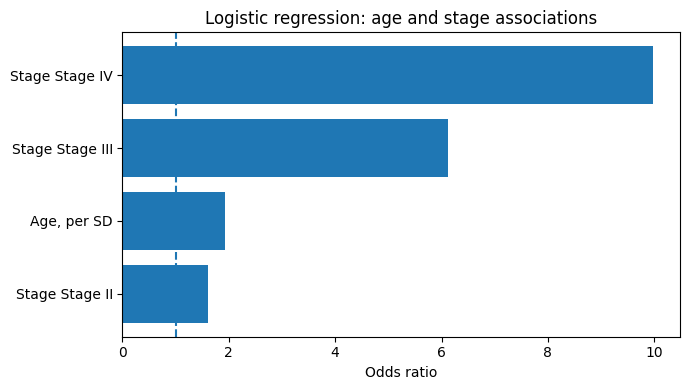

In [18]:
def clean_feature_label(feature: str) -> str:
    label = feature

    label = label.replace("num__", "")
    label = label.replace("cat__", "")

    if label == "age":
        return "Age, per SD"

    label = label.replace("stage_group_", "Stage ")
    label = label.replace("race_", "Race: ")
    label = label.replace("menopause_status_", "Menopause: ")
    label = label.replace("histological_type_", "Histology: ")

    return label


coef_df["clean_label"] = coef_df["feature"].apply(clean_feature_label)

coef_plot_df = coef_df[
    coef_df["feature"].str.contains("age|stage_group", regex=True)
].copy()

coef_plot_df = coef_plot_df.sort_values("odds_ratio")

plt.figure(figsize=(7, 4))
plt.barh(coef_plot_df["clean_label"], coef_plot_df["odds_ratio"])
plt.axvline(1, linestyle="--")
plt.xlabel("Odds ratio")
plt.title("Logistic regression: age and stage associations")
plt.tight_layout()

plt.savefig(
    FIG_DIR / "brca_ml_logistic_odds_ratios.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

---

**Summary of outputs produced by this notebook:**

| File | Description |
|---|---|
| `data/processed/brca_ml_three_year_status_summary.csv` | 3-year outcome label distribution |
| `data/processed/brca_ml_model_comparison.csv` | AUC, accuracy, and other metrics for all three models |
| `data/processed/brca_ml_test_predictions.csv` | Test-set predicted probabilities and labels |
| `data/processed/brca_ml_feature_importance.csv` | Random forest Gini importances (top 15) |
| `data/processed/brca_ml_logistic_coefficients.csv` | Logistic regression coefficients and odds ratios |
| `figures/brca_ml_roc_curves.png` | ROC curves for all models |
| `figures/brca_ml_auc_comparison.png` | Bar chart of AUC by model |
| `figures/brca_ml_confusion_matrix_best_model.png` | Confusion matrix (Logistic Regression) |
| `figures/brca_ml_feature_importance.png` | RF feature importance plot |
| `figures/brca_ml_logistic_odds_ratios.png` | Logistic regression odds ratio plot |

*This notebook is part of the TCGA Breast Cancer Survival Analysis project. All outputs are consumed by the Streamlit dashboard in `app_1.py`.*